
========== Fold: u1 ==========
Jumlah user (train): 943
Jumlah item (train): 1650
Jumlah rating (train): 80000


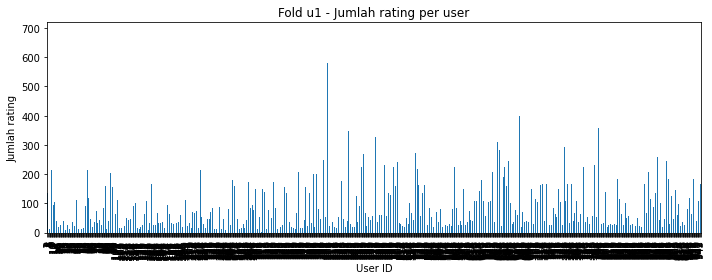

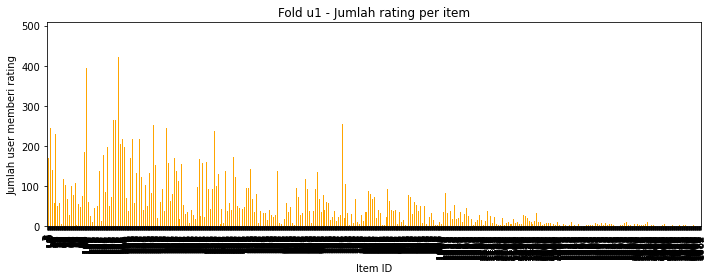

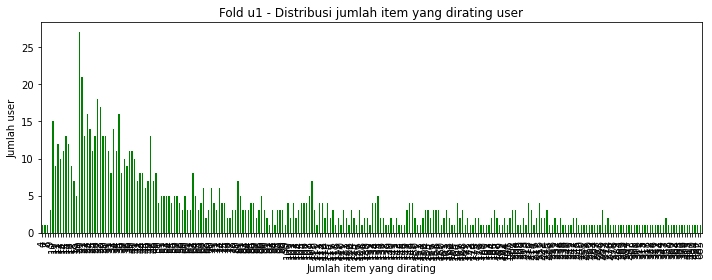


========== Fold: u2 ==========
Jumlah user (train): 943
Jumlah item (train): 1648
Jumlah rating (train): 80000


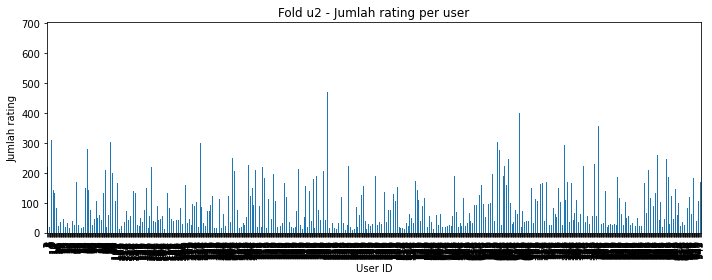

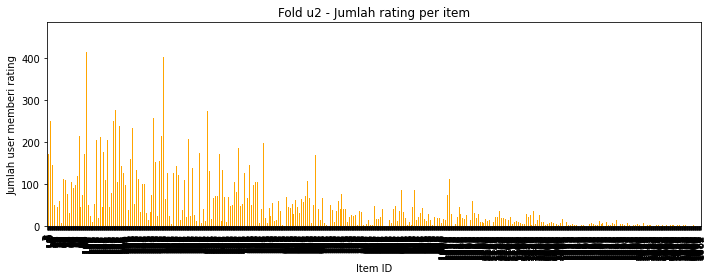

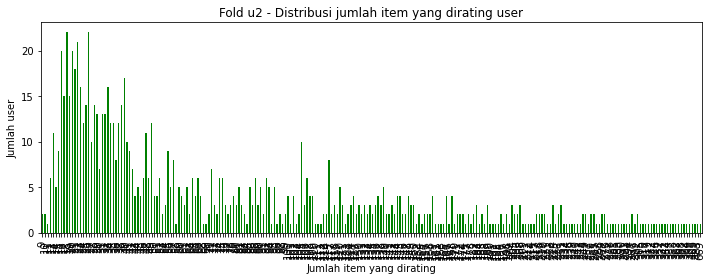


========== Fold: u3 ==========
Jumlah user (train): 943
Jumlah item (train): 1650
Jumlah rating (train): 80000


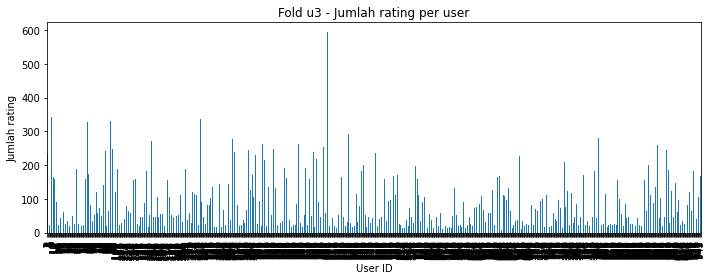

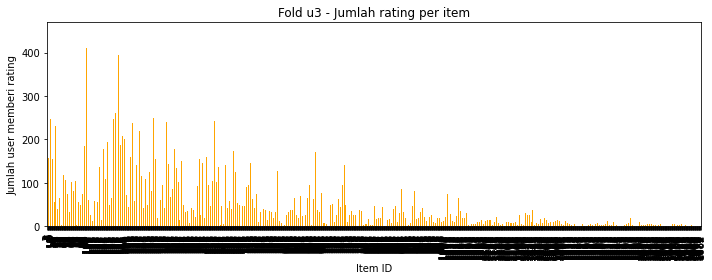

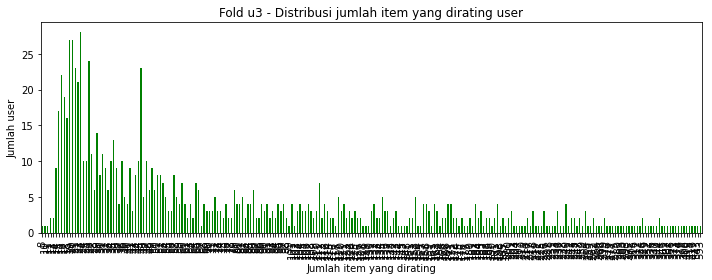


========== Fold: u4 ==========
Jumlah user (train): 943
Jumlah item (train): 1660
Jumlah rating (train): 80000


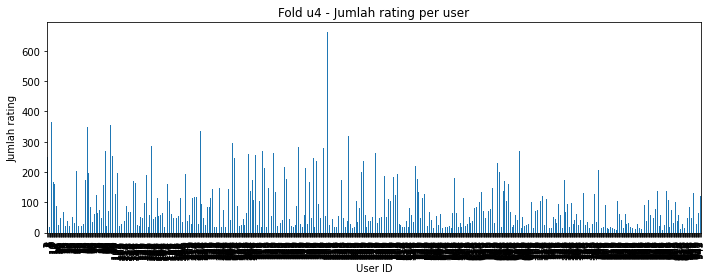

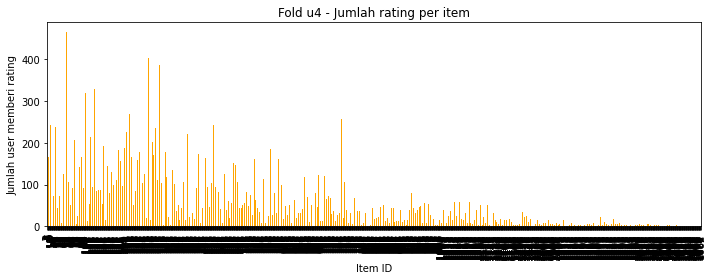

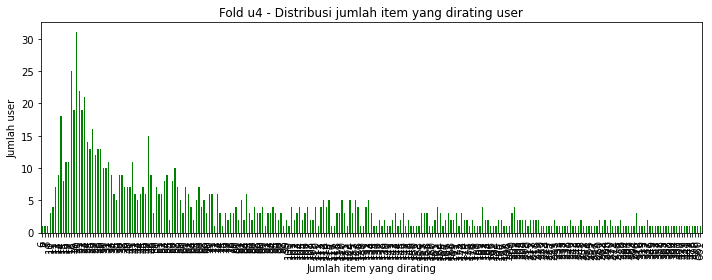


========== Fold: u5 ==========
Jumlah user (train): 943
Jumlah item (train): 1650
Jumlah rating (train): 80000


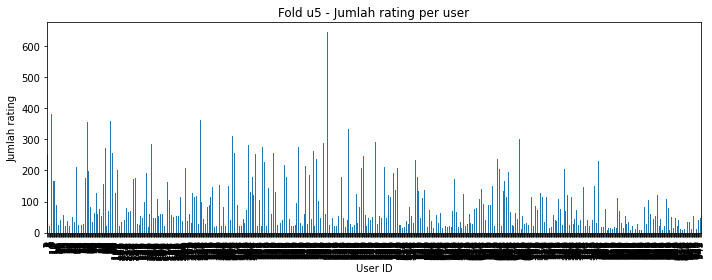

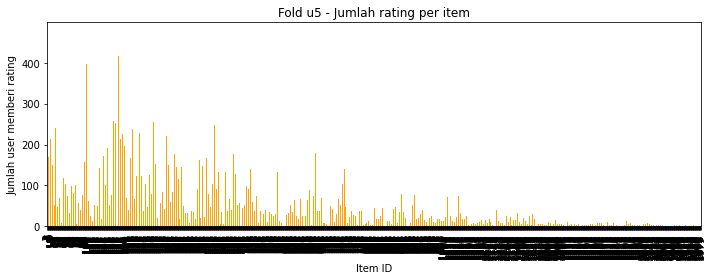

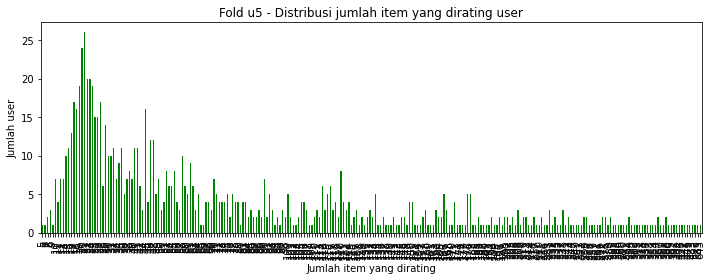

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Daftar nama file fold
folds = ['u1', 'u2', 'u3', 'u4', 'u5']

for fold in folds:
    print(f"\n========== Fold: {fold} ==========")
    
    base_file = f'ml-100k/{fold}.base'
    test_file = f'ml-100k/{fold}.test'

    # Load data base dan test
    col_names = ['user_id', 'item_id', 'rating', 'timestamp']

    
    df_base = pd.read_csv(base_file, sep='\t', names=col_names)
    df_test = pd.read_csv(test_file, sep='\t', names=col_names)

    # Hapus kolom timestamp (tidak dipakai)
    df_base.drop(columns='timestamp', inplace=True)
    df_test.drop(columns='timestamp', inplace=True)

    # (a) Statistik dasar
    num_users = df_base['user_id'].nunique()
    num_items = df_base['item_id'].nunique()
    num_ratings = len(df_base)

    print(f"Jumlah user (train): {num_users}")
    print(f"Jumlah item (train): {num_items}")
    print(f"Jumlah rating (train): {num_ratings}")

    # (b) Jumlah rating per user
    user_rating_counts = df_base.groupby('user_id')['item_id'].count()

    # Visualisasi
    user_rating_counts.sort_index().plot(kind='bar', figsize=(10,4))
    plt.title(f'Fold {fold} - Jumlah rating per user')
    plt.xlabel('User ID')
    plt.ylabel('Jumlah rating')
    plt.tight_layout()
    plt.show()

    # (c) Jumlah rating per item
    item_rating_counts = df_base.groupby('item_id')['user_id'].count()

    item_rating_counts.sort_index().plot(kind='bar', figsize=(10,4), color='orange')
    plt.title(f'Fold {fold} - Jumlah rating per item')
    plt.xlabel('Item ID')
    plt.ylabel('Jumlah user memberi rating')
    plt.tight_layout()
    plt.show()

    # (d) Distribusi jumlah item yang dirating per user
    item_per_user = df_base.groupby('user_id')['item_id'].count()
    distribusi = item_per_user.value_counts().sort_index()

    distribusi.plot(kind='bar', figsize=(10,4), color='green')
    plt.title(f'Fold {fold} - Distribusi jumlah item yang dirating user')
    plt.xlabel('Jumlah item yang dirating')
    plt.ylabel('Jumlah user')
    plt.tight_layout()
    plt.show()


In [6]:
import pandas as pd
import os

folds = ['u1', 'u2', 'u3', 'u4', 'u5']
col_names = ['user_id', 'item_id', 'rating', 'timestamp']
summary = []

# Writer Excel
with pd.ExcelWriter('statistik_dataset.xlsx') as writer:
    # Statistik keseluruhan
    full_df = pd.concat([pd.read_csv(f'ml-100k/{f}.base', sep='\t', names=col_names) for f in folds])
    full_df.drop(columns='timestamp', inplace=True)

    stat_all = {
        'Jumlah user': [full_df['user_id'].nunique()],
        'Jumlah item': [full_df['item_id'].nunique()],
        'Jumlah rating': [len(full_df)]
    }
    df_all = pd.DataFrame(stat_all)
    df_all.to_excel(writer, sheet_name='Semua Fold', index=False)

    # Per Fold
    for fold in folds:
        df_base = pd.read_csv(f'ml-100k/{fold}.base', sep='\t', names=col_names).drop(columns='timestamp')
        df_test = pd.read_csv(f'ml-100k/{fold}.test', sep='\t', names=col_names).drop(columns='timestamp')

        # Statistik dasar
        stat = {
            'Nama Fold': fold,
            'Jumlah user (train)': df_base['user_id'].nunique(),
            'Jumlah item (train)': df_base['item_id'].nunique(),
            'Jumlah rating (train)': len(df_base),
            'Jumlah user (test)': df_test['user_id'].nunique(),
            'Jumlah item (test)': df_test['item_id'].nunique(),
            'Jumlah rating (test)': len(df_test)
        }
        summary.append(stat)

        # Tambahan: rating per user dan item (train)
        user_counts = df_base.groupby('user_id')['item_id'].count().reset_index(name='jumlah_rating')
        item_counts = df_base.groupby('item_id')['user_id'].count().reset_index(name='jumlah_user')

        distribusi_item_per_user = user_counts['jumlah_rating'].value_counts().sort_index().reset_index()
        distribusi_item_per_user.columns = ['jumlah_item_dirating', 'jumlah_user']

        # Simpan ke sheet per fold
        pd.DataFrame([stat]).to_excel(writer, sheet_name=fold.upper() + '_Statistik', index=False)
        user_counts.to_excel(writer, sheet_name=fold.upper() + '_UserRating', index=False)
        item_counts.to_excel(writer, sheet_name=fold.upper() + '_ItemRating', index=False)
        distribusi_item_per_user.to_excel(writer, sheet_name=fold.upper() + '_Distribusi', index=False)

    # Rekap semua fold
    df_summary = pd.DataFrame(summary)
    df_summary.to_excel(writer, sheet_name='Ringkasan Fold', index=False)
